# 一人当たりに直して考えてみる

In [1]:
# csvファイル　country_population.csvを読み込む
import csv
with open(r"C:\修論研究\VWT_historical_data\country_population.csv", 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)
        

['Country Name', 'Country Code', 'Year', 'Value']
['Aruba', 'ABW', '1960', '54922']
['Aruba', 'ABW', '1961', '55578']
['Aruba', 'ABW', '1962', '56320']
['Aruba', 'ABW', '1963', '57002']
['Aruba', 'ABW', '1964', '57619']
['Aruba', 'ABW', '1965', '58190']
['Aruba', 'ABW', '1966', '58694']
['Aruba', 'ABW', '1967', '58990']
['Aruba', 'ABW', '1968', '59069']
['Aruba', 'ABW', '1969', '59052']
['Aruba', 'ABW', '1970', '58950']
['Aruba', 'ABW', '1971', '58781']
['Aruba', 'ABW', '1972', '58047']
['Aruba', 'ABW', '1973', '58299']
['Aruba', 'ABW', '1974', '58349']
['Aruba', 'ABW', '1975', '58295']
['Aruba', 'ABW', '1976', '58368']
['Aruba', 'ABW', '1977', '58580']
['Aruba', 'ABW', '1978', '58776']
['Aruba', 'ABW', '1979', '59191']
['Aruba', 'ABW', '1980', '59909']
['Aruba', 'ABW', '1981', '60563']
['Aruba', 'ABW', '1982', '61276']
['Aruba', 'ABW', '1983', '62228']
['Aruba', 'ABW', '1984', '62901']
['Aruba', 'ABW', '1985', '61728']
['Aruba', 'ABW', '1986', '59931']
['Aruba', 'ABW', '1987', '59159'

# netを人口で割ってみる

In [2]:
from __future__ import annotations

from typing import Optional, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm


ISO3_FIX = {
    "FR": "FRA",
    "UK": "GBR",
    "EL": "GRC",
    "SP": "ESP",
    "SW": "SWE",
    "NO": "NOR",
    "JA": "JPN",
    "KO": "KOR",
    "CH": "CHN",
    "FR1": "FRA",
}

USSR_ALIASES = {"USSR", "SUN", "USS"}
USSR_NAME_ALIASES = {
    "USSR",
    "SOVIET UNION",
    "UNION OF SOVIET SOCIALIST REPUBLICS",
}


def _normalize_zip_shp_path(path: str) -> str:
    path = str(path)
    if path.startswith("zip://"):
        return path
    if ".zip!" in path.lower():
        return "zip://" + path
    return path


def _clean_iso3(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.upper()
    return s.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "-99": np.nan})


def _find_column(columns, *, exact=None, contains=None) -> Optional[str]:
    exact = exact or []
    contains = contains or []

    lowered = {str(c).strip().lower(): c for c in columns}
    for key in exact:
        if key.lower() in lowered:
            return lowered[key.lower()]

    for c in columns:
        low = str(c).strip().lower()
        if any(token.lower() in low for token in contains):
            return c
    return None


def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world = world.copy()
    world["_iso3"] = _clean_iso3(world["ISO_A3"])
    invalid = world["_iso3"].isna()

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isna()

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isna()

    world["_iso3"] = world["_iso3"].replace(ISO3_FIX)
    world.loc[invalid, "_iso3"] = np.nan
    return world


def extract_population_by_iso3_for_year(
    population_df: pd.DataFrame,
    year: int,
    *,
    iso3_col: Optional[str] = None,
    year_col: Optional[str] = None,
    pop_col: Optional[str] = None,
    ussr_until_year: int = 1991,
) -> pd.DataFrame:
    if population_df is None or len(population_df) == 0:
        raise ValueError("population_df が空です。")

    pop = population_df.copy()
    y = int(year)

    if iso3_col is None:
        iso3_col = _find_column(
            pop.columns,
            exact=["iso3", "iso_a3", "iso-3", "iso_3", "country code", "country_code", "code"],
            contains=["iso3"],
        )
    if iso3_col is None:
        raise ValueError(
            f"人口データの ISO3 列を特定できません。iso3_col を指定してください。columns={list(pop.columns)}"
        )

    if year_col is not None or pop_col is not None:
        if year_col is None or pop_col is None:
            raise ValueError("year_col と pop_col はセットで指定してください。")
        long = pop[[iso3_col, year_col, pop_col]].copy()
        long["_year"] = pd.to_numeric(long[year_col], errors="coerce")
        long = long[long["_year"] == y]
        out = long[[iso3_col, pop_col]].rename(columns={iso3_col: "iso3", pop_col: "population"})
    else:
        year_col_wide = None
        for c in pop.columns:
            if str(c).strip() == str(y):
                year_col_wide = c
                break

        if year_col_wide is not None:
            out = pop[[iso3_col, year_col_wide]].rename(columns={iso3_col: "iso3", year_col_wide: "population"})
        else:
            auto_year_col = _find_column(pop.columns, exact=["year", "yr"], contains=["year"])
            auto_pop_col = _find_column(pop.columns, exact=["population", "pop", "value"], contains=["pop"])
            if auto_year_col is None or auto_pop_col is None:
                raise ValueError(
                    "人口データ形式を自動判定できません。"
                    " long形式なら year_col/pop_col、wide形式なら年列（例: '2015'）を確認してください。"
                )
            long = pop[[iso3_col, auto_year_col, auto_pop_col]].copy()
            long["_year"] = pd.to_numeric(long[auto_year_col], errors="coerce")
            long = long[long["_year"] == y]
            out = long[[iso3_col, auto_pop_col]].rename(columns={iso3_col: "iso3", auto_pop_col: "population"})

    out = out.copy()
    out["iso3"] = _clean_iso3(out["iso3"]).replace(ISO3_FIX)
    if y <= int(ussr_until_year):
        out["iso3"] = out["iso3"].replace({k: "RUS" for k in USSR_ALIASES})

    out["population"] = pd.to_numeric(out["population"], errors="coerce")
    out = out[out["iso3"].notna() & np.isfinite(out["population"]) & (out["population"] > 0)].copy()
    out = out.groupby("iso3", as_index=False)["population"].sum()
    return out


def plot_vwt_net_import_export_map_debug_percapita(
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    population_df: pd.DataFrame,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    xlim=(-180, 180),
    ylim=(-60, 85),
    top_n_print: int = 20,
    percapita_unit: str = "m^3/person/year",
    cmap: str = "seismic",
    clip_quantile: Optional[float] = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    show_missing_legend: bool = True,
    debug_iso3: str = "FRA",
    print_no_match_samples: int = 30,
    print_df_only_samples: int = 30,
    ussr_until_year: int = 1991,
) -> Tuple[pd.DataFrame, gpd.GeoDataFrame]:
    debug_iso3 = str(debug_iso3).strip().upper()
    y = int(year)
    pop_y = int(population_year) if population_year is not None else y
    pre_ussr = y <= int(ussr_until_year)

    if pre_ussr and debug_iso3 in USSR_ALIASES:
        debug_iso3 = "RUS"

    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    vwt_mat = np.load(vwt_path).astype(float)
    if vwt_mat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt_mat.shape}")

    nrow, ncol = vwt_mat.shape
    if nrow != ncol:
        print(f"[WARN] VWTmat is not square: {vwt_mat.shape}. row/colの向きを要確認")

    n = min(nrow, ncol)
    vwt_mat = vwt_mat[:n, :n]
    print("VWTmat shape:", vwt_mat.shape)
    print("VWT file:", vwt_path)

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]

    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    import_by_country = np.nansum(vwt_mat, axis=0)
    export_by_country = np.nansum(vwt_mat, axis=1)

    df_net = pd.DataFrame(
        {
            "iso3_raw": cl_n["_iso3"].values,
            "import": import_by_country,
            "export": export_by_country,
        }
    )
    if pre_ussr:
        df_net["iso3"] = df_net["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
    else:
        df_net["iso3"] = df_net["iso3_raw"]

    df_net = df_net[df_net["iso3"].notna()].copy()
    df_net = df_net.groupby("iso3", as_index=False)[["import", "export"]].sum()
    df_net["net"] = df_net["import"] - df_net["export"]

    pop_by_iso3 = extract_population_by_iso3_for_year(
        population_df=population_df,
        year=pop_y,
        iso3_col=pop_iso3_col,
        year_col=pop_year_col,
        pop_col=pop_value_col,
        ussr_until_year=ussr_until_year,
    )
    print(f"population year: {pop_y}, rows={len(pop_by_iso3)}")

    df_net = df_net.merge(pop_by_iso3, on="iso3", how="left")
    valid_pop = np.isfinite(df_net["population"]) & (df_net["population"] > 0)
    for col in ["import", "export", "net"]:
        df_net[f"{col}_pc"] = np.where(valid_pop, df_net[col] / df_net["population"], np.nan)

    print(f"population valid ratio: {int(valid_pop.sum())}/{len(df_net)}")

    df_pos = df_net[df_net["net_pc"] > 0].sort_values("net_pc", ascending=False)
    df_neg = df_net[df_net["net_pc"] < 0].sort_values("net_pc", ascending=True)
    print(f"\nTop {top_n_print} net per-capita positive (net_pc>0):")
    print(df_pos.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])
    print(f"\nTop {top_n_print} net per-capita negative (net_pc<0):")
    print(df_neg.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    m = world.merge(df_net, left_on="_iso3", right_on="iso3", how="left")

    print("\n" + "=" * 70)
    print(f"[DEBUG] Investigate ISO3 = {debug_iso3}")
    print("=" * 70)
    print(f"[DEBUG] world has {debug_iso3}? ->", (world["_iso3"] == debug_iso3).any())
    print(f"[DEBUG] df_net has {debug_iso3}? ->", (df_net["iso3"] == debug_iso3).any())
    if (df_net["iso3"] == debug_iso3).any():
        print(df_net[df_net["iso3"] == debug_iso3][["iso3", "population", "import_pc", "export_pc", "net_pc"]].head(5))

    no_match = m[m["_iso3"].notna() & m["net_pc"].isna()][["_iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample world-iso3 but missing in df_net/pop (no match): n={len(no_match)}")
    print(no_match.head(print_no_match_samples).to_string(index=False))

    net_only = df_net[~df_net["iso3"].isin(world["_iso3"].dropna())][["iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample df_net iso3 but missing in world: n={len(net_only)}")
    print(net_only.head(print_df_only_samples).to_string(index=False))
    print("=" * 70 + "\n")

    vals = m["net_pc"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("net_pc の有効値が無い（人口マージ失敗 or population<=0）。")

    absvals = np.abs(vals)
    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(absvals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(absvals))
    else:
        vmax = float(np.nanmax(absvals))

    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(f"Virtual-water net per capita (import - export) [{percapita_unit}] | {year} (crop={crop})", fontsize=14)

    m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)
    has = np.isfinite(m["net_pc"].astype(float))
    m.loc[has].plot(
        ax=ax,
        column="net_pc",
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        legend=True,
        zorder=2,
    )
    m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

    if show_missing_legend:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match / no population")],
            loc="lower left",
            frameon=True,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return df_net, m


VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_56_2015.npy
population year: 2015, rows=265
population valid ratio: 210/231

Top 20 net per-capita positive (net_pc>0):
    iso3  population   import_pc  export_pc      net_pc
97   ISR   8380100.0  228.075742   2.874240  225.201502
48   CYP   1219502.0  205.877992   2.166671  203.711321
151  NLD  16939923.0  225.583028  57.956807  167.626222
93   IRL   4701957.0  175.857451  17.100656  158.756796
108  KOR  51014947.0  132.895004   0.000609  132.894395
144  NAM   2374300.0  123.402563   0.001156  123.401406
167  PRT  10358076.0  106.755133   1.689157  105.065976
45   CRI   4818038.0  101.163552   0.006979  101.156573
194  SWZ   1142813.0  100.717067   1.601610   99.115456
60   ESP  46422303.0  101.863540   2.920646   98.942894
142  MYS  31232798.0   97.337495   0.139021   97.198474
31   BWA   2203273.0   95.318165   0.031554   95.286612
55   DZA  40019529.0   86.412916   0.000000   86.412916
54   DOM  10434829.0 

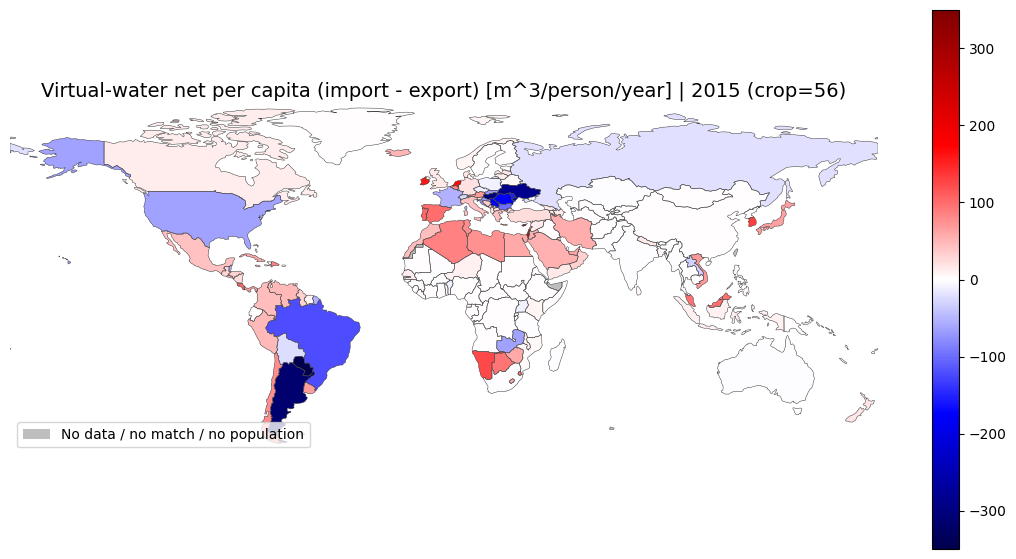

In [12]:
import csv
import pandas as pd
from percapita_utils import plot_vwt_net_import_export_map_debug_percapita

COUNTRY_POP_CSV   = r"C:\修論研究\VWT_historical_data\country_population.csv"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

# country_population.csv を読み込み（Country Code, Year, Value）
rows = []
with open(COUNTRY_POP_CSV, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

country_population = pd.DataFrame(rows)

df_net_pc, merged_map_pc = plot_vwt_net_import_export_map_debug_percapita(
    year=2015,
    crop=56,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    population_df=country_population,
    pop_iso3_col="Country Code",
    pop_year_col="Year",
    pop_value_col="Value",
    debug_iso3="RUS",
)


# アニメーション

In [4]:
from __future__ import annotations

from typing import Optional, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.animation import FuncAnimation
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm


ISO3_FIX = {
    "FR": "FRA",
    "UK": "GBR",
    "EL": "GRC",
    "SP": "ESP",
    "SW": "SWE",
    "NO": "NOR",
    "JA": "JPN",
    "KO": "KOR",
    "CH": "CHN",
    "FR1": "FRA",
}

USSR_ALIASES = {"USSR", "SUN", "USS"}
USSR_NAME_ALIASES = {
    "USSR",
    "SOVIET UNION",
    "UNION OF SOVIET SOCIALIST REPUBLICS",
}
INVALID_ISO3 = {"-99", "NAN", "NONE", ""}


def _normalize_zip_shp_path(path: str) -> str:
    path = str(path)
    if path.startswith("zip://"):
        return path
    if ".zip!" in path.lower():
        return "zip://" + path
    return path


def _clean_iso3(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.upper()
    return s.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "-99": np.nan})


def _find_column(columns, *, exact=None, contains=None) -> Optional[str]:
    exact = exact or []
    contains = contains or []

    lowered = {str(c).strip().lower(): c for c in columns}
    for key in exact:
        if key.lower() in lowered:
            return lowered[key.lower()]

    for c in columns:
        low = str(c).strip().lower()
        if any(token.lower() in low for token in contains):
            return c
    return None


def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world = world.copy()
    world["_iso3"] = _clean_iso3(world["ISO_A3"])
    invalid = world["_iso3"].isna()

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isna()

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isna()

    world["_iso3"] = world["_iso3"].replace(ISO3_FIX)
    world.loc[invalid, "_iso3"] = np.nan
    return world


def extract_population_by_iso3_for_year(
    population_df: pd.DataFrame,
    year: int,
    *,
    iso3_col: Optional[str] = None,
    year_col: Optional[str] = None,
    pop_col: Optional[str] = None,
    ussr_until_year: int = 1991,
) -> pd.DataFrame:
    if population_df is None or len(population_df) == 0:
        raise ValueError("population_df が空です。")

    pop = population_df.copy()
    y = int(year)

    if iso3_col is None:
        iso3_col = _find_column(
            pop.columns,
            exact=["iso3", "iso_a3", "iso-3", "iso_3", "country code", "country_code", "code"],
            contains=["iso3"],
        )
    if iso3_col is None:
        raise ValueError(
            f"人口データの ISO3 列を特定できません。iso3_col を指定してください。columns={list(pop.columns)}"
        )

    if year_col is not None or pop_col is not None:
        if year_col is None or pop_col is None:
            raise ValueError("year_col と pop_col はセットで指定してください。")
        long = pop[[iso3_col, year_col, pop_col]].copy()
        long["_year"] = pd.to_numeric(long[year_col], errors="coerce")
        long = long[long["_year"] == y]
        out = long[[iso3_col, pop_col]].rename(columns={iso3_col: "iso3", pop_col: "population"})
    else:
        year_col_wide = None
        for c in pop.columns:
            if str(c).strip() == str(y):
                year_col_wide = c
                break

        if year_col_wide is not None:
            out = pop[[iso3_col, year_col_wide]].rename(columns={iso3_col: "iso3", year_col_wide: "population"})
        else:
            auto_year_col = _find_column(pop.columns, exact=["year", "yr"], contains=["year"])
            auto_pop_col = _find_column(pop.columns, exact=["population", "pop", "value"], contains=["pop"])
            if auto_year_col is None or auto_pop_col is None:
                raise ValueError(
                    "人口データ形式を自動判定できません。"
                    " long形式なら year_col/pop_col、wide形式なら年列（例: '2015'）を確認してください。"
                )
            long = pop[[iso3_col, auto_year_col, auto_pop_col]].copy()
            long["_year"] = pd.to_numeric(long[auto_year_col], errors="coerce")
            long = long[long["_year"] == y]
            out = long[[iso3_col, auto_pop_col]].rename(columns={iso3_col: "iso3", auto_pop_col: "population"})

    out = out.copy()
    out["iso3"] = _clean_iso3(out["iso3"]).replace(ISO3_FIX)
    if y <= int(ussr_until_year):
        out["iso3"] = out["iso3"].replace({k: "RUS" for k in USSR_ALIASES})

    out["population"] = pd.to_numeric(out["population"], errors="coerce")
    out = out[out["iso3"].notna() & np.isfinite(out["population"]) & (out["population"] > 0)].copy()
    out = out.groupby("iso3", as_index=False)["population"].sum()
    return out


def plot_vwt_net_import_export_map_debug_percapita(
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    population_df: pd.DataFrame,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    xlim=(-180, 180),
    ylim=(-60, 85),
    top_n_print: int = 20,
    base_unit: str = "m^3/year",
    percapita_unit: str = "m^3/person/year",
    cmap: str = "seismic",
    clip_quantile: Optional[float] = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    show_missing_legend: bool = True,
    debug_iso3: str = "FRA",
    print_no_match_samples: int = 30,
    print_df_only_samples: int = 30,
    ussr_until_year: int = 1991,
) -> Tuple[pd.DataFrame, gpd.GeoDataFrame]:
    debug_iso3 = str(debug_iso3).strip().upper()
    y = int(year)
    pop_y = int(population_year) if population_year is not None else y
    pre_ussr = y <= int(ussr_until_year)

    if pre_ussr and debug_iso3 in USSR_ALIASES:
        debug_iso3 = "RUS"

    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    vwt_mat = np.load(vwt_path).astype(float)
    if vwt_mat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt_mat.shape}")

    nrow, ncol = vwt_mat.shape
    if nrow != ncol:
        print(f"[WARN] VWTmat is not square: {vwt_mat.shape}. row/colの向きを要確認")

    n = min(nrow, ncol)
    vwt_mat = vwt_mat[:n, :n]
    print("VWTmat shape:", vwt_mat.shape)
    print("VWT file:", vwt_path)

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]

    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    import_by_country = np.nansum(vwt_mat, axis=0)
    export_by_country = np.nansum(vwt_mat, axis=1)

    df_net = pd.DataFrame(
        {
            "iso3_raw": cl_n["_iso3"].values,
            "import": import_by_country,
            "export": export_by_country,
        }
    )
    if pre_ussr:
        df_net["iso3"] = df_net["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
    else:
        df_net["iso3"] = df_net["iso3_raw"]

    df_net = df_net[df_net["iso3"].notna()].copy()
    df_net = df_net.groupby("iso3", as_index=False)[["import", "export"]].sum()
    df_net["net"] = df_net["import"] - df_net["export"]

    pop_by_iso3 = extract_population_by_iso3_for_year(
        population_df=population_df,
        year=pop_y,
        iso3_col=pop_iso3_col,
        year_col=pop_year_col,
        pop_col=pop_value_col,
        ussr_until_year=ussr_until_year,
    )
    print(f"population year: {pop_y}, rows={len(pop_by_iso3)}")

    df_net = df_net.merge(pop_by_iso3, on="iso3", how="left")
    valid_pop = np.isfinite(df_net["population"]) & (df_net["population"] > 0)
    for col in ["import", "export", "net"]:
        df_net[f"{col}_pc"] = np.where(valid_pop, df_net[col] / df_net["population"], np.nan)

    print(f"population valid ratio: {int(valid_pop.sum())}/{len(df_net)}")

    df_pos = df_net[df_net["net_pc"] > 0].sort_values("net_pc", ascending=False)
    df_neg = df_net[df_net["net_pc"] < 0].sort_values("net_pc", ascending=True)
    print(f"\nTop {top_n_print} net per-capita positive (net_pc>0):")
    print(df_pos.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])
    print(f"\nTop {top_n_print} net per-capita negative (net_pc<0):")
    print(df_neg.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    m = world.merge(df_net, left_on="_iso3", right_on="iso3", how="left")

    print("\n" + "=" * 70)
    print(f"[DEBUG] Investigate ISO3 = {debug_iso3}")
    print("=" * 70)
    print(f"[DEBUG] world has {debug_iso3}? ->", (world["_iso3"] == debug_iso3).any())
    print(f"[DEBUG] df_net has {debug_iso3}? ->", (df_net["iso3"] == debug_iso3).any())
    if (df_net["iso3"] == debug_iso3).any():
        print(df_net[df_net["iso3"] == debug_iso3][["iso3", "population", "import_pc", "export_pc", "net_pc"]].head(5))

    no_match = m[m["_iso3"].notna() & m["net_pc"].isna()][["_iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample world-iso3 but missing in df_net/pop (no match): n={len(no_match)}")
    print(no_match.head(print_no_match_samples).to_string(index=False))

    net_only = df_net[~df_net["iso3"].isin(world["_iso3"].dropna())][["iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample df_net iso3 but missing in world: n={len(net_only)}")
    print(net_only.head(print_df_only_samples).to_string(index=False))
    print("=" * 70 + "\n")

    vals = m["net_pc"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("net_pc の有効値が無い（人口マージ失敗 or population<=0）。")

    absvals = np.abs(vals)
    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(absvals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(absvals))
    else:
        vmax = float(np.nanmax(absvals))

    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(f"Virtual-water net per capita (import - export) [{percapita_unit}] | {year} (crop={crop})", fontsize=14)

    m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)
    has = np.isfinite(m["net_pc"].astype(float))
    m.loc[has].plot(
        ax=ax,
        column="net_pc",
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        legend=True,
        zorder=2,
    )
    m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

    if show_missing_legend:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match / no population")],
            loc="lower left",
            frameon=True,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return df_net, m


def animate_vwt_net_import_export_percapita(
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    population_df: pd.DataFrame,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    xlim=(-180, 180),
    ylim=(-60, 85),
    percapita_unit: str = "m^3/person/year",
    fps: int = 6,
    interval_ms: Optional[int] = None,
    out_mp4: Optional[str] = None,
    out_gif: Optional[str] = None,
    dpi: int = 150,
    cmap: str = "seismic",
    clip_quantile: Optional[float] = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    show_missing_legend: bool = True,
    ussr_until_year: int = 1991,
) -> FuncAnimation:
    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定してください。")
    if interval_ms is None:
        interval_ms = int(1000 / max(1, int(fps)))

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    n = min(vwt0.shape[0], vwt0.shape[1])
    if vwt0.shape[0] != vwt0.shape[1]:
        print(f"[WARN] VWTmat is not square: {vwt0.shape}. row/colの向きを要確認")
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]
    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)

    pop_cache: dict[int, pd.DataFrame] = {}
    netpc_by_year: dict[int, pd.DataFrame] = {}
    global_abs_vals = []

    for y in years:
        vwt_y = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        if vwt_y.ndim != 2:
            raise ValueError(f"年{y}のVWTmatが2次元でない: shape={vwt_y.shape}")
        if min(vwt_y.shape[0], vwt_y.shape[1]) < n:
            raise ValueError(f"年{y}のVWTサイズが小さい: {vwt_y.shape}, expected at least {n}x{n}")
        if vwt_y.shape[0] != vwt_y.shape[1]:
            print(f"[WARN] year={y}: VWTmat is not square: {vwt_y.shape}. row/colの向きを要確認")
        vwt_y = vwt_y[:n, :n]

        import_by_country = np.nansum(vwt_y, axis=0)
        export_by_country = np.nansum(vwt_y, axis=1)
        df_y = pd.DataFrame(
            {
                "iso3_raw": cl_n["_iso3"].values,
                "import": import_by_country,
                "export": export_by_country,
            }
        )
        if y <= int(ussr_until_year):
            df_y["iso3"] = df_y["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
        else:
            df_y["iso3"] = df_y["iso3_raw"]

        df_y = df_y[df_y["iso3"].notna()].copy()
        df_y = df_y.groupby("iso3", as_index=False)[["import", "export"]].sum()
        df_y["net"] = df_y["import"] - df_y["export"]

        pop_y = int(population_year) if population_year is not None else int(y)
        if pop_y not in pop_cache:
            pop_cache[pop_y] = extract_population_by_iso3_for_year(
                population_df=population_df,
                year=pop_y,
                iso3_col=pop_iso3_col,
                year_col=pop_year_col,
                pop_col=pop_value_col,
                ussr_until_year=ussr_until_year,
            )

        df_y = df_y.merge(pop_cache[pop_y], on="iso3", how="left")
        valid_pop = np.isfinite(df_y["population"]) & (df_y["population"] > 0)
        df_y["net_pc"] = np.where(valid_pop, df_y["net"] / df_y["population"], np.nan)
        netpc_by_year[y] = df_y[["iso3", "net_pc"]].copy()

        vals = df_y["net_pc"].to_numpy(dtype=float)
        vals = vals[np.isfinite(vals)]
        if vals.size > 0:
            global_abs_vals.append(np.abs(vals))

    if len(global_abs_vals) == 0:
        raise ValueError("全年で net_pc の有効値が無い（人口マージ失敗 or population<=0）。")
    global_abs_vals = np.concatenate(global_abs_vals)

    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(global_abs_vals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(global_abs_vals))
    else:
        vmax = float(np.nanmax(global_abs_vals))

    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0

    print(f"Global per-capita scale: vmax={vmax:g} (clip_quantile={clip_quantile})")
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(f"net per capita (import - export) [{percapita_unit}]")

    def update(frame_i: int):
        y = years[frame_i]
        ax.cla()
        ax.set_axis_off()
        pop_label = int(population_year) if population_year is not None else y
        ax.set_title(
            f"Virtual-water net per capita (import - export) [{percapita_unit}] | {y} (pop={pop_label}, crop={crop})",
            fontsize=14,
        )

        m = world.merge(netpc_by_year[y], left_on="_iso3", right_on="iso3", how="left")
        m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)

        has = np.isfinite(m["net_pc"].astype(float))
        if has.any():
            m.loc[has].plot(
                ax=ax,
                column="net_pc",
                cmap=cmap,
                norm=norm,
                linewidth=0.0,
                edgecolor="none",
                legend=False,
                zorder=2,
            )

        m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

        if show_missing_legend:
            from matplotlib.patches import Patch

            ax.legend(
                handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match / no population")],
                loc="lower left",
                frameon=True,
            )

        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        return []

    anim = FuncAnimation(fig, update, frames=len(years), interval=interval_ms, blit=False)

    if out_mp4:
        anim.save(out_mp4, writer="ffmpeg", fps=fps, dpi=dpi)
        print("Saved MP4:", out_mp4)

    if out_gif:
        anim.save(out_gif, writer="pillow", fps=fps, dpi=dpi)
        print("Saved GIF:", out_gif)

    return anim


Global per-capita scale: vmax=1549.48 (clip_quantile=0.995)
Saved GIF: C:\修論研究\VWT_historical_data\net_pc_crop15_1986_2016.gif


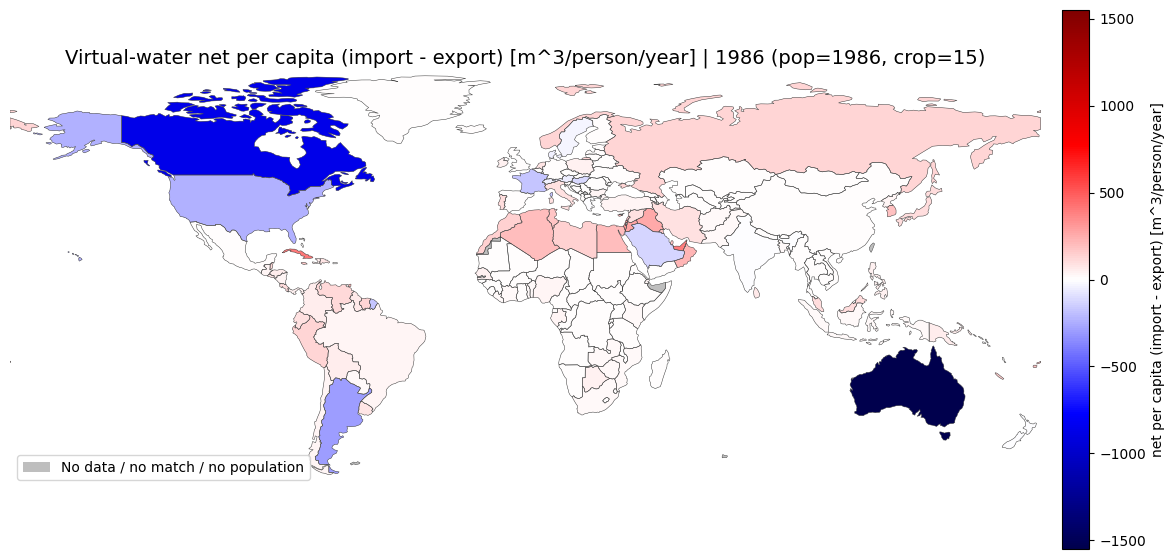

In [6]:
import csv
import pandas as pd
from percapita_utils import animate_vwt_net_import_export_percapita

COUNTRY_POP_CSV   = r"C:\修論研究\VWT_historical_data\country_population.csv"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

rows = []
with open(COUNTRY_POP_CSV, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

country_population = pd.DataFrame(rows)

anim = animate_vwt_net_import_export_percapita(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    population_df=country_population,   # ここがポイント
    pop_iso3_col="Country Code",
    pop_year_col="Year",
    pop_value_col="Value",
    fps=6,
    out_gif=r"C:\修論研究\VWT_historical_data\net_pc_crop15_1986_2016.gif",
    cmap="seismic",
    clip_quantile=0.995,
)


In [7]:
# percapita_utils.py に追加した関数
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd

# 既存の補助関数/定数を使う前提:
# _find_column, _clean_iso3, extract_population_by_iso3_for_year
# ISO3_FIX, USSR_ALIASES, USSR_NAME_ALIASES

def save_vwt_net_and_percapita_npy_by_year(
    crop: int,
    year_start: int,
    year_end: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    population_df: pd.DataFrame,
    out_dir: str,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    net_npy_template: str = "net_{crop}_{year}.npy",
    net_pc_npy_template: str = "net_pc_{crop}_{year}.npy",
    iso3_order_npy: str = "iso3_order.npy",
    save_iso3_each_year: bool = False,
    iso3_yearly_npy_template: str = "iso3_{crop}_{year}.npy",
    ussr_until_year: int = 1991,
) -> pd.DataFrame:
    years = list(range(int(year_start), int(year_end) + 1))
    if len(years) == 0:
        raise ValueError("year_start <= year_end になるように指定してください。")

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")

    vwt0 = np.load(vwt_npy_template.format(crop=crop, year=years[0])).astype(float)
    if vwt0.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt0.shape}")

    n = min(vwt0.shape[0], vwt0.shape[1])
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]
    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    iso3_order = (
        cl_n["_iso3"]
        .replace({k: "RUS" for k in USSR_ALIASES})
        .dropna()
        .astype(str)
        .sort_values()
        .drop_duplicates()
        .to_numpy()
    )
    if iso3_order.size == 0:
        raise ValueError("iso3_order が空です。country_list のISO3を確認してください。")

    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    np.save(out_path / iso3_order_npy, iso3_order)

    pop_cache: dict[int, pd.DataFrame] = {}
    summary_rows = []

    for y in years:
        vwt_y = np.load(vwt_npy_template.format(crop=crop, year=y)).astype(float)
        vwt_y = vwt_y[:n, :n]

        import_by_country = np.nansum(vwt_y, axis=0)
        export_by_country = np.nansum(vwt_y, axis=1)
        df_y = pd.DataFrame(
            {
                "iso3_raw": cl_n["_iso3"].values,
                "import": import_by_country,
                "export": export_by_country,
            }
        )

        if int(y) <= int(ussr_until_year):
            df_y["iso3"] = df_y["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
        else:
            df_y["iso3"] = df_y["iso3_raw"]

        df_y = df_y[df_y["iso3"].notna()].copy()
        df_y = df_y.groupby("iso3", as_index=False)[["import", "export"]].sum()
        df_y["net"] = df_y["import"] - df_y["export"]

        pop_y = int(population_year) if population_year is not None else int(y)
        if pop_y not in pop_cache:
            pop_cache[pop_y] = extract_population_by_iso3_for_year(
                population_df=population_df,
                year=pop_y,
                iso3_col=pop_iso3_col,
                year_col=pop_year_col,
                pop_col=pop_value_col,
                ussr_until_year=ussr_until_year,
            )
        df_y = df_y.merge(pop_cache[pop_y], on="iso3", how="left")

        valid_pop = np.isfinite(df_y["population"]) & (df_y["population"] > 0)
        df_y["net_pc"] = np.where(valid_pop, df_y["net"] / df_y["population"], np.nan)

        aligned = df_y.set_index("iso3").reindex(iso3_order)
        net_arr = aligned["net"].to_numpy(dtype=float)
        net_pc_arr = aligned["net_pc"].to_numpy(dtype=float)

        net_name = net_npy_template.format(crop=crop, year=y)
        net_pc_name = net_pc_npy_template.format(crop=crop, year=y)
        np.save(out_path / net_name, net_arr)
        np.save(out_path / net_pc_name, net_pc_arr)

        if save_iso3_each_year:
            iso_name = iso3_yearly_npy_template.format(crop=crop, year=y)
            np.save(out_path / iso_name, iso3_order)

        summary_rows.append(
            {
                "year": int(y),
                "pop_year": int(pop_y),
                "n_iso3": int(iso3_order.size),
                "n_valid_population": int(np.isfinite(net_pc_arr).sum()),
                "net_npy": str(out_path / net_name),
                "net_pc_npy": str(out_path / net_pc_name),
            }
        )

    summary = pd.DataFrame(summary_rows)
    print(f"Saved yearly npy: years={years[0]}-{years[-1]}, files={len(years) * 2}")
    print(f"Saved iso3 order: {out_path / iso3_order_npy} (n={iso3_order.size})")
    return summary


In [9]:
import importlib
import percapita_utils

print(percapita_utils.__file__)  # 読み込まれている実体を確認
percapita_utils = importlib.reload(percapita_utils)

print(hasattr(percapita_utils, "save_vwt_net_and_percapita_npy_by_year"))


c:\修論研究\codes\percapita_utils.py
True


In [10]:
summary = percapita_utils.save_vwt_net_and_percapita_npy_by_year(
    crop=15,
    year_start=1986,
    year_end=2016,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    population_df=country_population,
    out_dir=r"C:\修論研究\VWT_historical_data\net_npy",
    pop_iso3_col="Country Code",
    pop_year_col="Year",
    pop_value_col="Value",
)
summary.head()


Saved yearly npy: years=1986-2016, files=62
Saved iso3 order: C:\修論研究\VWT_historical_data\net_npy\iso3_order.npy (n=230)


,year,pop_year,n_iso3,n_valid_population,net_npy,net_pc_npy
0,1986,1986,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
1,1987,1987,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
2,1988,1988,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
3,1989,1989,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_198...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...
4,1990,1990,230,210,C:\修論研究\VWT_historical_data\net_npy\net_15_199...,C:\修論研究\VWT_historical_data\net_npy\net_pc_15_...


# GDPとの見比べ

In [5]:
%pip install -U xlrd>=2.0.1


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


crop=15 (Wheat) available years: [1986, 1987, 1988, 1989, 1990] ... [2012, 2013, 2014, 2015, 2016] (n=31)


,crop_id,crop_name,year,iso3,gdp_pc,population,import_total,import_pc,vwt_npy_path
0,15,Wheat,1986,ABW,6767.559229,59931.0,2.318699e+05,3.868948,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_198...
1,15,Wheat,1986,AGO,697.526602,10139450.0,6.087210e+06,0.600349,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_198...
2,15,Wheat,1986,ALB,693.873475,3022635.0,0.000000e+00,0.000000,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_198...
3,15,Wheat,1986,AND,10539.117787,45734.0,1.805313e+05,3.947419,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_198...
4,15,Wheat,1986,ARE,23132.073968,1467383.0,5.742994e+08,391.376638,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_198...


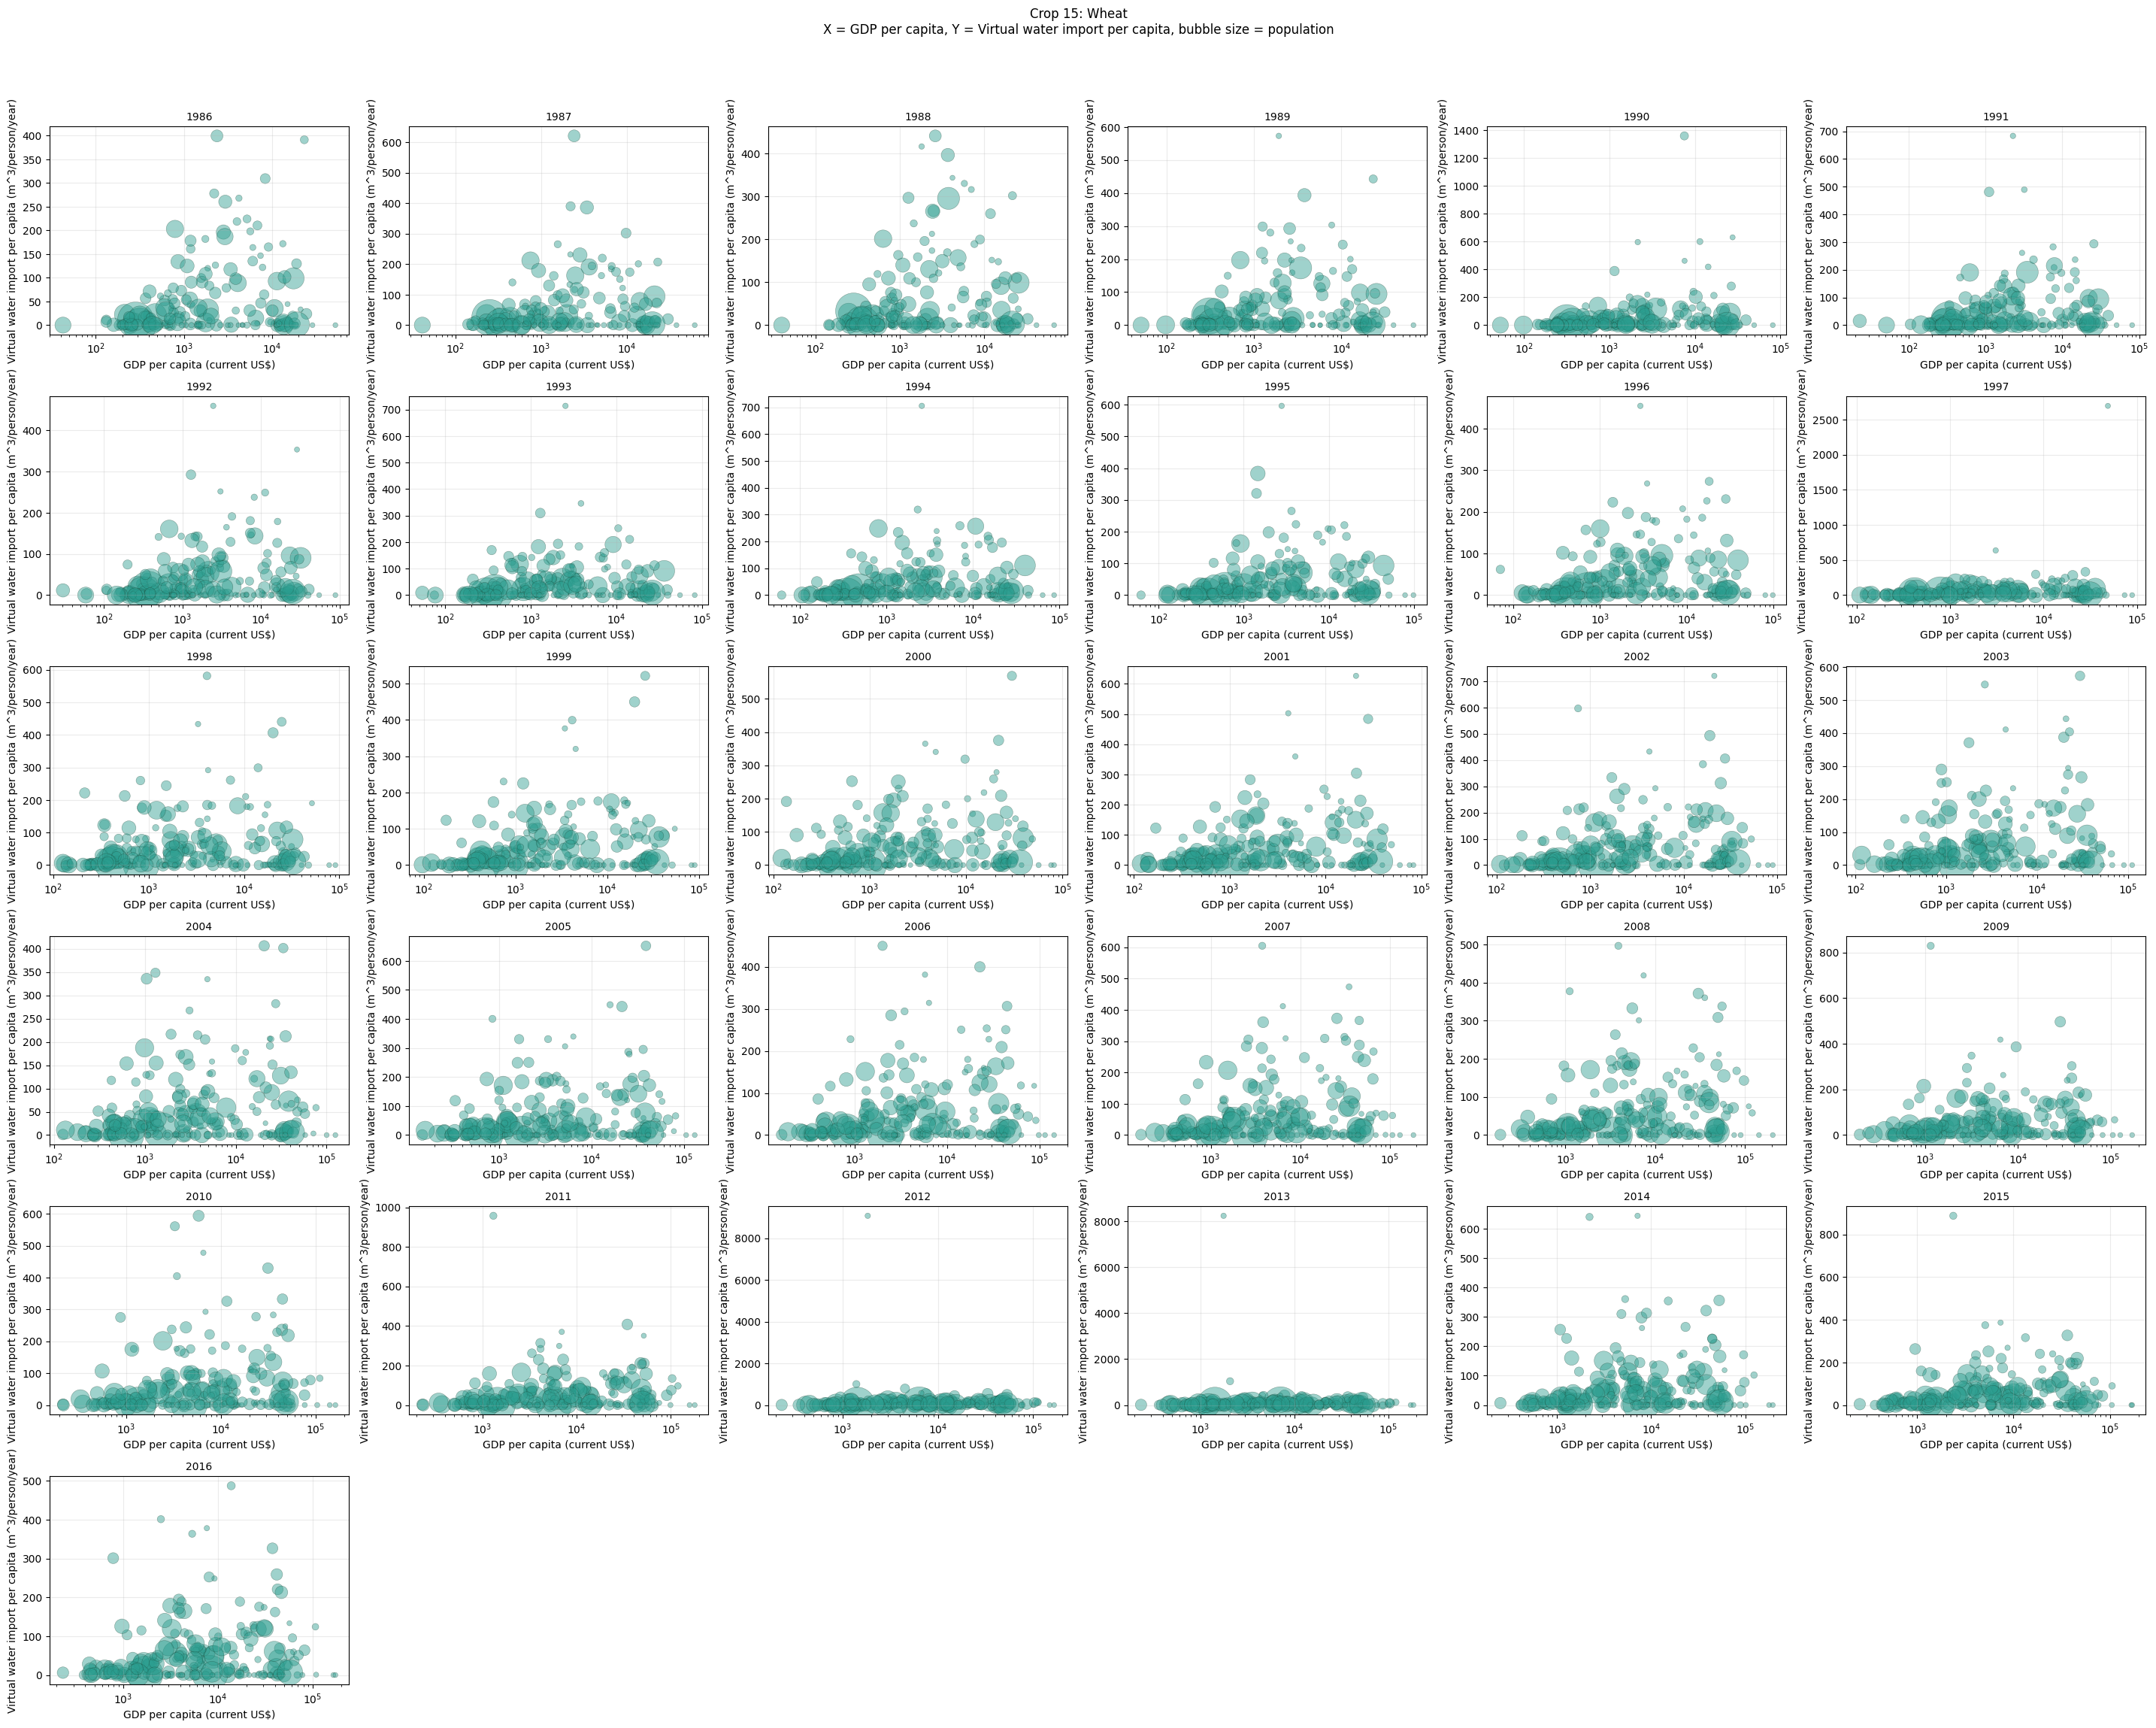

saved: C:\修論研究\VWT_historical_data\bubble_crop15_analysis\bubble_gdp_importpc_crop15_Wheat.png


,year,n_countries,pearson_loggdp_importpc,spearman_loggdp_importpc,median_gdp_pc,median_import_pc
0,1986,167,0.264111,0.250213,1469.421764,11.139266
1,1987,173,0.193843,0.202428,1567.032051,9.609506
2,1988,175,0.192897,0.186739,1632.014817,12.999128
3,1989,175,0.170627,0.159105,1670.215207,7.563297
4,1990,191,0.220155,0.240007,1610.980271,9.141040
5,1991,192,0.151695,0.182125,1562.619833,10.183017
6,1992,193,0.191336,0.212819,1559.381006,13.563828
7,1993,194,0.100835,0.148898,1619.347743,13.786799
8,1994,194,0.167369,0.205881,1773.321477,12.162075
9,1995,197,0.158111,0.205422,2108.006982,11.703146


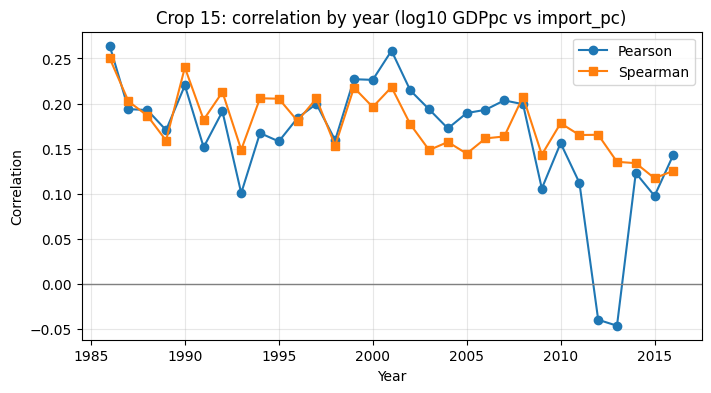

Top 20 by import_pc (2016)


,iso3,gdp_pc,population,import_total,import_pc
0,LVA,13838.526682,1959537.0,9.549963e+08,487.358127
1,DJI,2510.430008,1037653.0,4.164794e+08,401.366714
2,VCT,7656.900429,106349.0,4.022181e+07,378.205841
3,FJI,5363.790267,919166.0,3.343117e+08,363.712012
4,ISR,37671.538914,8546000.0,2.789398e+09,326.398048
5,TJK,788.710482,8865631.0,2.668193e+09,300.959137
6,BEL,41854.549830,11331422.0,2.935573e+09,259.064835
7,LBN,8089.012088,6323060.0,1.596313e+09,252.459013
8,GRD,9221.234611,115130.0,2.860803e+07,248.484583
9,ARE,42721.099938,8935095.0,1.972299e+09,220.736260


Top 20 by import_total (2016)


,iso3,gdp_pc,population,import_total,import_pc
0,IDN,3521.469435,2.646274e+08,1.454700e+10,54.971645
1,EGY,3270.628777,1.016446e+08,1.207295e+10,118.776115
2,BRA,8836.285460,2.032181e+08,9.416877e+09,46.338769
3,PHL,2985.195640,1.067357e+08,7.943031e+09,74.417744
4,JPN,39375.473162,1.270760e+08,7.755140e+09,61.027573
5,ITA,31391.569290,6.011522e+07,7.160433e+09,119.111813
6,DZA,4424.985290,4.085072e+07,6.731612e+09,164.785645
7,MAR,3140.855469,3.502346e+07,6.257055e+09,178.653277
8,KOR,30832.062807,5.121780e+07,6.240214e+09,121.836818
9,MEX,9097.923977,1.222514e+08,6.174099e+09,50.503318


In [7]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 設定
# =========================
CROP_ID = 15
FOCUS_YEAR = 2016  # ランキング表示年

VWT_NPY_DIR       = r"C:\修論研究\VWT_historical_data\VWT_npy"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
ITEM_LIST_XLSX    = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
POP_CSV           = r"C:\修論研究\VWT_historical_data\country_population.csv"  # Country Code, Year, Value
GDP_XLS           = r"C:\修論研究\VWT_historical_data\API_NY.GDP.PCAP.CD_DS2_en_excel_v2_281.xls"
OUT_DIR           = r"C:\修論研究\VWT_historical_data\bubble_crop15_analysis"

N_COLS = 6
SHOW_TOP_N = 20
ANNOTATE_TOP_POP = 0  # 0なら注釈なし

# =========================
# 補助関数
# =========================
ISO3_FIX = {
    "UK": "GBR", "EL": "GRC", "SP": "ESP", "SW": "SWE", "NO": "NOR",
    "JA": "JPN", "KO": "KOR", "CH": "CHN", "FR1": "FRA",
}
USSR_ALIASES = {"USSR", "SUN", "USS"}
USSR_NAME_ALIASES = {
    "USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"
}

def clean_iso3(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.upper()
    s = s.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "-99": np.nan})
    return s.replace(ISO3_FIX)

def find_column(columns, exact=None, contains=None):
    exact = exact or []
    contains = contains or []
    lowered = {str(c).strip().lower(): c for c in columns}
    for key in exact:
        if key.lower() in lowered:
            return lowered[key.lower()]
    for c in columns:
        lc = str(c).strip().lower()
        if any(tok.lower() in lc for tok in contains):
            return c
    return None

def detect_wb_header_row(raw_df: pd.DataFrame, max_scan=20) -> int:
    # World Bank Excelのヘッダ行（Country Name / Country Code）を探す
    for i in range(min(len(raw_df), max_scan)):
        vals = [str(v).strip().lower() for v in raw_df.iloc[i].tolist()]
        if ("country name" in vals) and ("country code" in vals):
            return i
    return 0

def load_wb_excel_wide_by_iso3(excel_path: str, sheet_name=0) -> pd.DataFrame:
    import re
    raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None, engine="xlrd")

    h = detect_wb_header_row(raw)
    header = raw.iloc[h].tolist()
    df = raw.iloc[h+1:].copy()
    df.columns = header

    code_col = find_column(df.columns, exact=["Country Code", "country code"], contains=["country code"])
    if code_col is None:
        raise ValueError(f"GDP ExcelでCountry Code列が見つかりません。columns={list(df.columns)}")

    # ---- 年列を robust に検出（1960 / '1960' / 1960.0 / '1960.0' 対応）----
    year_map = {}  # {"1960": original_col_name, ...}
    for c in df.columns:
        y = None
        if isinstance(c, (int, np.integer)):
            yi = int(c)
            if 1800 <= yi <= 2100:
                y = str(yi)
        elif isinstance(c, (float, np.floating)):
            if np.isfinite(c) and float(c).is_integer():
                yi = int(c)
                if 1800 <= yi <= 2100:
                    y = str(yi)
        else:
            s = str(c).strip()
            m = re.fullmatch(r"(\d{4})(?:\.0+)?", s)
            if m:
                yi = int(m.group(1))
                if 1800 <= yi <= 2100:
                    y = str(yi)
        if y is not None:
            year_map[y] = c

    if len(year_map) == 0:
        raise ValueError(f"GDP Excelで年列が見つかりません。columns先頭={list(df.columns)[:12]}")

    ordered_years = sorted(year_map.keys(), key=int)
    use_cols = [code_col] + [year_map[y] for y in ordered_years]

    out = df[use_cols].copy()
    rename_dict = {code_col: "iso3"}
    rename_dict.update({year_map[y]: y for y in ordered_years})
    out = out.rename(columns=rename_dict)

    out["iso3"] = clean_iso3(out["iso3"])
    for y in ordered_years:
        out[y] = pd.to_numeric(out[y], errors="coerce")

    out = out[out["iso3"].notna()].groupby("iso3", as_index=False)[ordered_years].mean(numeric_only=True)
    return out



def load_population_wide_by_iso3(pop_csv: str) -> pd.DataFrame:
    # 前に使っていた long形式: Country Name, Country Code, Year, Value
    df = pd.read_csv(pop_csv)

    code_col = find_column(df.columns, exact=["Country Code", "country code"], contains=["country code"])
    year_col = find_column(df.columns, exact=["Year", "year"], contains=["year"])
    val_col  = find_column(df.columns, exact=["Value", "value"], contains=["value", "population", "pop"])

    # もしwide形式ならそのまま処理
    year_cols = [c for c in df.columns if str(c).strip().isdigit()]
    if code_col is not None and len(year_cols) > 0:
        out = df[[code_col] + year_cols].copy()
        out = out.rename(columns={code_col: "iso3"})
        out["iso3"] = clean_iso3(out["iso3"])
        for c in year_cols:
            out[c] = pd.to_numeric(out[c], errors="coerce")
        out = out[out["iso3"].notna()].groupby("iso3", as_index=False)[year_cols].mean(numeric_only=True)
        return out

    # long形式をwideに変換
    if code_col is None or year_col is None or val_col is None:
        raise ValueError(f"population CSVの列を解釈できません。columns={list(df.columns)}")

    long_df = df[[code_col, year_col, val_col]].copy()
    long_df.columns = ["iso3", "year", "value"]
    long_df["iso3"] = clean_iso3(long_df["iso3"])
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")
    long_df = long_df[
        long_df["iso3"].notna() &
        np.isfinite(long_df["year"]) &
        np.isfinite(long_df["value"])
    ].copy()
    long_df["year"] = long_df["year"].astype(int)

    out = (
        long_df.pivot_table(index="iso3", columns="year", values="value", aggfunc="mean")
        .reset_index()
        .rename_axis(None, axis=1)
    )
    out.columns = [str(int(c)) if isinstance(c, (int, np.integer)) else str(c) for c in out.columns]
    return out

def extract_year_series(wide_df: pd.DataFrame, year: int, value_name: str) -> pd.DataFrame:
    y = str(int(year))
    if y not in wide_df.columns:
        return pd.DataFrame({"iso3": wide_df["iso3"], value_name: np.nan})
    out = wide_df[["iso3", y]].copy().rename(columns={y: value_name})
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    out = out.groupby("iso3", as_index=False)[value_name].mean()
    return out

def scale_bubble_sizes(pop: pd.Series, smin=20, smax=1200) -> np.ndarray:
    p = pd.to_numeric(pop, errors="coerce").to_numpy(dtype=float)
    s = np.full_like(p, fill_value=float(smin), dtype=float)
    valid = np.isfinite(p) & (p > 0)
    if valid.sum() == 0:
        return s
    root = np.sqrt(p[valid])
    lo, hi = float(np.nanmin(root)), float(np.nanmax(root))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        s[valid] = (smin + smax) / 2.0
        return s
    s[valid] = smin + (root - lo) / (hi - lo) * (smax - smin)
    return s

# =========================
# データ読み込み
# =========================
out_dir = Path(OUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

country_list = pd.read_excel(COUNTRY_LIST_XLSX)
iso3_col = find_column(country_list.columns, exact=["ISO3", "iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
if iso3_col is None:
    raise ValueError(f"country_listにISO3列が見つかりません。columns={list(country_list.columns)}")

country_name_col = find_column(country_list.columns, exact=["Country name", "Country Name"], contains=["country"])
if country_name_col is None:
    country_name_col = country_list.columns[0]

item_df = pd.read_excel(ITEM_LIST_XLSX)
item_name_map = {}
if item_df.shape[1] >= 2:
    ids = pd.to_numeric(item_df.iloc[:, 1], errors="coerce")
    names = item_df.iloc[:, 0].astype(str).str.strip()
    tmp = pd.DataFrame({"crop_id": ids, "crop_name": names}).dropna(subset=["crop_id"])
    tmp["crop_id"] = tmp["crop_id"].astype(int)
    tmp["crop_name"] = tmp["crop_name"].replace({"": np.nan}).fillna(tmp["crop_id"].map(lambda x: f"item_{x}"))
    item_name_map = dict(tmp.drop_duplicates("crop_id")[["crop_id", "crop_name"]].values.tolist())
crop_name = item_name_map.get(CROP_ID, f"item_{CROP_ID}")

pop_wide = load_population_wide_by_iso3(POP_CSV)
gdp_wide = load_wb_excel_wide_by_iso3(GDP_XLS, sheet_name=0)

# crop=15 の利用可能年を取得
pat = re.compile(rf"^VWT_{CROP_ID}_(\d+)\.npy$")
years = []
for p in Path(VWT_NPY_DIR).glob(f"VWT_{CROP_ID}_*.npy"):
    m = pat.match(p.name)
    if m:
        years.append(int(m.group(1)))
years = sorted(set(years))

if len(years) == 0:
    raise ValueError(f"VWT_{CROP_ID}_*.npy が見つかりません: {VWT_NPY_DIR}")

print(f"crop={CROP_ID} ({crop_name}) available years: {years[:5]} ... {years[-5:]} (n={len(years)})")

# =========================
# scatterデータ作成（年ごと）
# =========================
all_rows = []

for year in years:
    vwt_path = Path(VWT_NPY_DIR) / f"VWT_{CROP_ID}_{year}.npy"
    if not vwt_path.exists():
        continue

    vwt = np.load(vwt_path).astype(float)
    if vwt.ndim != 2:
        print(f"[SKIP] year={year}: shape={vwt.shape}")
        continue

    n = min(vwt.shape[0], vwt.shape[1])
    if len(country_list) < n:
        print(f"[SKIP] year={year}: country_list rows({len(country_list)}) < VWT size({n})")
        continue

    cl_n = country_list.iloc[:n].copy()
    cl_n["_iso3"] = clean_iso3(cl_n[iso3_col])
    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    miss = cl_n["_iso3"].isna()
    cl_n.loc[miss & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    # 輸入総量（列方向合計）
    import_total = np.nansum(vwt[:n, :n], axis=0)
    trade = pd.DataFrame({"iso3_raw": cl_n["_iso3"].values, "import_total": import_total})

    # 1991年以前はUSSR系をRUSへ寄せる
    if year <= 1991:
        trade["iso3"] = trade["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
    else:
        trade["iso3"] = trade["iso3_raw"]

    trade = trade[trade["iso3"].notna()].groupby("iso3", as_index=False)["import_total"].sum()

    pop_y = extract_year_series(pop_wide, year, "population")
    gdp_y = extract_year_series(gdp_wide, year, "gdp_pc")

    merged = trade.merge(pop_y, on="iso3", how="left").merge(gdp_y, on="iso3", how="left")

    valid_pop = np.isfinite(merged["population"]) & (merged["population"] > 0)
    merged["import_pc"] = np.where(valid_pop, merged["import_total"] / merged["population"], np.nan)

    merged["crop_id"] = CROP_ID
    merged["crop_name"] = crop_name
    merged["year"] = year
    merged["vwt_npy_path"] = str(vwt_path)

    merged = merged[
        np.isfinite(merged["gdp_pc"]) & (merged["gdp_pc"] > 0) &
        np.isfinite(merged["import_pc"]) &
        np.isfinite(merged["population"]) & (merged["population"] > 0)
    ].copy()

    all_rows.append(
        merged[["crop_id", "crop_name", "year", "iso3", "gdp_pc", "population", "import_total", "import_pc", "vwt_npy_path"]]
    )

if len(all_rows) == 0:
    raise ValueError("有効な散布図データが作れませんでした。")

scatter_df = pd.concat(all_rows, ignore_index=True).sort_values(["year", "iso3"]).reset_index(drop=True)
display(scatter_df.head())

# =========================
# バブル散布図（crop=15の全年度をサブプロット）
# =========================
n = len(years)
ncols = max(1, N_COLS)
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.8*ncols, 3.9*nrows), squeeze=False)
axes_flat = axes.flatten()

for i, year in enumerate(years):
    ax = axes_flat[i]
    d = scatter_df[scatter_df["year"] == year].copy()
    if len(d) == 0:
        ax.set_axis_off()
        continue

    sizes = scale_bubble_sizes(d["population"], smin=20, smax=1200)

    ax.scatter(
        d["gdp_pc"], d["import_pc"],
        s=sizes, alpha=0.45,
        c="#2A9D8F", edgecolors="#1B4332", linewidths=0.4
    )
    ax.set_xscale("log")
    ax.set_title(str(year), fontsize=10)
    ax.set_xlabel("GDP per capita (current US$)")
    ax.set_ylabel("Virtual water import per capita (m^3/person/year)")
    ax.grid(True, alpha=0.25)

    if ANNOTATE_TOP_POP > 0:
        top = d.nlargest(ANNOTATE_TOP_POP, "population")
        for r in top.itertuples(index=False):
            ax.annotate(str(r.iso3), (float(r.gdp_pc), float(r.import_pc)), fontsize=7, alpha=0.85)

for j in range(n, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.suptitle(
    f"Crop {CROP_ID}: {crop_name}\n"
    "X = GDP per capita, Y = Virtual water import per capita, bubble size = population",
    fontsize=12
)
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])

out_png = out_dir / f"bubble_gdp_importpc_crop{CROP_ID}_{crop_name}.png"
fig.savefig(out_png, dpi=170, bbox_inches="tight")
plt.show()
plt.close(fig)

print("saved:", out_png)

# =========================
# 年ごとの相関（log10(GDP/人) vs import_pc）
# =========================
corr_rows = []
for year, d in scatter_df.groupby("year"):
    if len(d) < 3:
        continue
    x = np.log10(d["gdp_pc"])
    y = d["import_pc"]
    corr_rows.append({
        "year": int(year),
        "n_countries": int(len(d)),
        "pearson_loggdp_importpc": float(x.corr(y, method="pearson")),
        "spearman_loggdp_importpc": float(x.corr(y, method="spearman")),
        "median_gdp_pc": float(d["gdp_pc"].median()),
        "median_import_pc": float(d["import_pc"].median()),
    })

annual_corr = pd.DataFrame(corr_rows).sort_values("year").reset_index(drop=True)
display(annual_corr)

plt.figure(figsize=(8,4))
plt.plot(annual_corr["year"], annual_corr["pearson_loggdp_importpc"], marker="o", label="Pearson")
plt.plot(annual_corr["year"], annual_corr["spearman_loggdp_importpc"], marker="s", label="Spearman")
plt.axhline(0, color="gray", lw=1)
plt.title(f"Crop {CROP_ID}: correlation by year (log10 GDPpc vs import_pc)")
plt.xlabel("Year")
plt.ylabel("Correlation")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# =========================
# 2016年ランキング
# =========================
d_focus = scatter_df[scatter_df["year"] == FOCUS_YEAR].copy()

print(f"Top {SHOW_TOP_N} by import_pc ({FOCUS_YEAR})")
display(
    d_focus.nlargest(SHOW_TOP_N, "import_pc")[["iso3", "gdp_pc", "population", "import_total", "import_pc"]]
    .reset_index(drop=True)
)

print(f"Top {SHOW_TOP_N} by import_total ({FOCUS_YEAR})")
display(
    d_focus.nlargest(SHOW_TOP_N, "import_total")[["iso3", "gdp_pc", "population", "import_total", "import_pc"]]
    .reset_index(drop=True)
)


figure file:


,crop_id,crop_name,n_years,year_min,year_max,n_points_total,out_png
0,15,Wheat,1,2016,2016,205,C:\修論研究\VWT_historical_data\bubble_crop_year_m...


points: 205 countries


,crop_id,crop_name,year,iso3,gdp_pc,population,import_total,import_pc,vwt_npy_path
0,15,Wheat,2016,ABW,27441.550214,108727.0,4.232087e+05,3.892397,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_201...
1,15,Wheat,2016,AFG,522.082216,34700612.0,6.721209e+08,19.369136,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_201...
2,15,Wheat,2016,AGO,2051.814621,29183070.0,1.601742e+05,0.005489,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_201...
3,15,Wheat,2016,ALB,4457.634122,2689469.0,2.921122e+08,108.613344,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_201...
4,15,Wheat,2016,AND,40129.838581,72181.0,0.000000e+00,0.000000,C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_201...


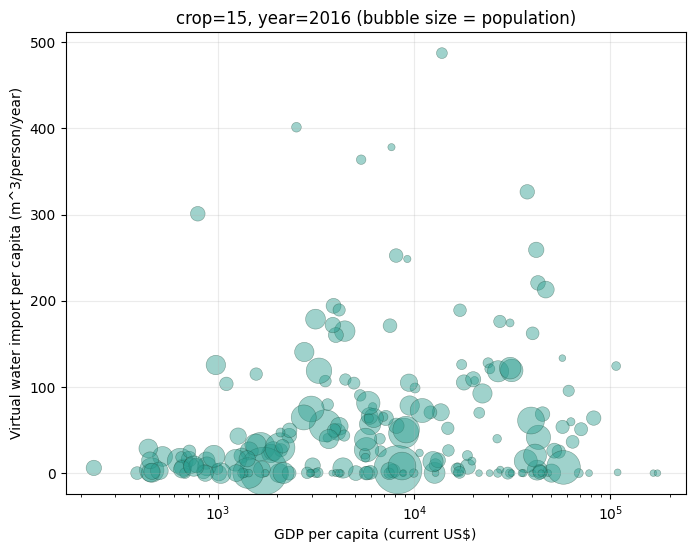

Top 20 by import_pc


,iso3,gdp_pc,population,import_total,import_pc
112,LVA,13838.526682,1959537.0,9.549963e+08,487.358127
49,DJI,2510.430008,1037653.0,4.164794e+08,401.366714
195,VCT,7656.900429,106349.0,4.022181e+07,378.205841
60,FJI,5363.790267,919166.0,3.343117e+08,363.712012
89,ISR,37671.538914,8546000.0,2.789398e+09,326.398048
181,TJK,788.710482,8865631.0,2.668193e+09,300.959137
14,BEL,41854.549830,11331422.0,2.935573e+09,259.064835
103,LBN,8089.012088,6323060.0,1.596313e+09,252.459013
73,GRD,9221.234611,115130.0,2.860803e+07,248.484583
5,ARE,42721.099938,8935095.0,1.972299e+09,220.736260


In [8]:
from importlib import reload
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import percapita_utils as pu

# percapita_utils.py の最新修正を反映
reload(pu)

# =========================
# パス設定
# =========================
VWT_NPY_DIR       = r"C:\修論研究\VWT_historical_data\VWT_npy"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
POP_CSV           = r"C:\修論研究\VWT_historical_data\country_population.csv"
GDP_XLS           = r"C:\修論研究\VWT_historical_data\API_NY.GDP.PCAP.CD_DS2_en_excel_v2_281.xls"
ITEM_LIST_XLSX    = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
OUT_DIR           = r"C:\修論研究\VWT_historical_data\bubble_crop_year_manual"

# =========================
# ここだけ毎回変更
# =========================
CROP_ID = 15
YEAR = 2016

# =========================
# 実行関数
# =========================
def bubble_size(pop, smin=20, smax=1200):
    p = pd.to_numeric(pop, errors="coerce").to_numpy(dtype=float)
    s = np.full_like(p, fill_value=float(smin), dtype=float)
    ok = np.isfinite(p) & (p > 0)
    if ok.sum() == 0:
        return s
    r = np.sqrt(p[ok])
    lo, hi = float(np.nanmin(r)), float(np.nanmax(r))
    if hi <= lo:
        s[ok] = (smin + smax) / 2.0
        return s
    s[ok] = smin + (r - lo) / (hi - lo) * (smax - smin)
    return s

def run_for(crop_id: int, year: int):
    avail = pu.list_available_vwt_item_years(VWT_NPY_DIR)
    hit = avail[(avail["crop_id"] == int(crop_id)) & (avail["year"] == int(year))]
    if len(hit) == 0:
        years_for_crop = sorted(avail.loc[avail["crop_id"] == int(crop_id), "year"].unique().tolist())
        raise ValueError(
            f"crop={crop_id}, year={year} のVWTデータがありません。"
            f"\nこのcropの利用可能年: {years_for_crop[:10]} ... {years_for_crop[-10:] if years_for_crop else []}"
        )

    scatter_df, fig_summary = pu.run_gdp_importpc_bubble_pipeline(
        vwt_npy_dir=VWT_NPY_DIR,
        country_list_xlsx=COUNTRY_LIST_XLSX,
        population_csv=POP_CSV,
        gdp_per_capita_xls=GDP_XLS,
        item_list_xlsx=ITEM_LIST_XLSX,
        crops=[int(crop_id)],
        years=[int(year)],
        output_dir=OUT_DIR,
        show_figures=False,
        ncols=1,
        log_x=True,
        annotate_top_n_population=0,
    )

    d = scatter_df[(scatter_df["crop_id"] == int(crop_id)) & (scatter_df["year"] == int(year))].copy()
    d = d.sort_values("iso3").reset_index(drop=True)

    print("figure file:")
    display(fig_summary)

    print(f"points: {len(d)} countries")
    display(d.head())

    # その場で1枚表示
    plt.figure(figsize=(8, 6))
    plt.scatter(
        d["gdp_pc"], d["import_pc"],
        s=bubble_size(d["population"]),
        alpha=0.45, c="#2A9D8F",
        edgecolors="#1B4332", linewidths=0.4
    )
    plt.xscale("log")
    plt.xlabel("GDP per capita (current US$)")
    plt.ylabel("Virtual water import per capita (m^3/person/year)")
    plt.title(f"crop={crop_id}, year={year} (bubble size = population)")
    plt.grid(alpha=0.25)
    plt.show()

    print("Top 20 by import_pc")
    display(d.nlargest(20, "import_pc")[["iso3", "gdp_pc", "population", "import_total", "import_pc"]])

    return d, fig_summary

# 実行
d_one, fig_info = run_for(CROP_ID, YEAR)


# netにするよ

crop=15 (Wheat), year=2016, n_countries=205


,iso3,import_total,export_total,net_total,population,gdp_pc,import_pc,export_pc,net_pc
0,ABW,4.232087e+05,0.00,4.232087e+05,108727.0,27441.550214,3.892397,0.000000,3.892397
1,AFG,6.721209e+08,0.00,6.721209e+08,34700612.0,522.082216,19.369136,0.000000,19.369136
2,AGO,1.601742e+05,0.00,1.601742e+05,29183070.0,2051.814621,0.005489,0.000000,0.005489
3,ALB,2.921122e+08,781735.84,2.913305e+08,2689469.0,4457.634122,108.613344,0.290665,108.322678
4,AND,0.000000e+00,0.00,0.000000e+00,72181.0,40129.838581,0.000000,0.000000,0.000000


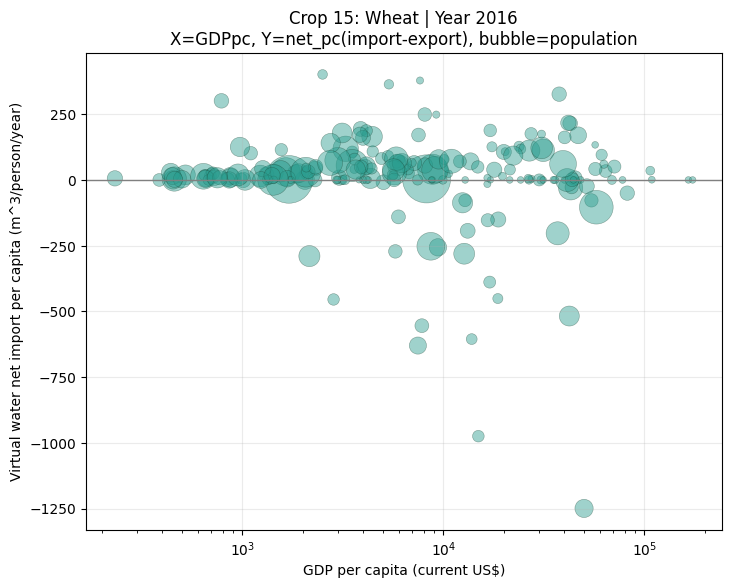

saved: C:\修論研究\VWT_historical_data\bubble_net_manual\bubble_net_crop15_2016_Wheat.png
Top 20 (net_pc: 輸入超過)


,iso3,gdp_pc,population,net_total,net_pc
0,DJI,2510.430008,1037653.0,4.164794e+08,401.366714
1,VCT,7656.900429,106349.0,4.022181e+07,378.205841
2,FJI,5363.790267,919166.0,3.343117e+08,363.712012
3,ISR,37671.538914,8546000.0,2.788430e+09,326.284765
4,TJK,788.710482,8865631.0,2.668193e+09,300.959137
5,LBN,8089.012088,6323060.0,1.573560e+09,248.860567
6,GRD,9221.234611,115130.0,2.860803e+07,248.484583
7,BEL,41854.549830,11331422.0,2.461262e+09,217.206792
8,ARE,42721.099938,8935095.0,1.922578e+09,215.171550
9,AZE,3880.685228,9757812.0,1.894110e+09,194.112205


Bottom 20 (net_pc: 輸出超過)


,iso3,gdp_pc,population,net_total,net_pc
0,AUS,50084.444061,24190907.0,-3.022690e+10,-1249.514956
1,LTU,14934.270284,2877325.0,-2.804494e+09,-974.687906
2,KAZ,7475.566887,18363600.0,-1.156910e+10,-630.001622
3,LVA,13838.526682,1959537.0,-1.186309e+09,-605.402631
4,BGR,7822.499233,6894139.0,-3.822122e+09,-554.401650
5,CAN,42314.061582,36110803.0,-1.869447e+10,-517.697297
6,MDA,2847.087948,2803186.0,-1.274489e+09,-454.657339
7,EST,18666.373652,1315790.0,-5.936003e+08,-451.136085
8,URY,17009.758421,3379283.0,-1.313322e+09,-388.639249
9,UKR,2158.461182,45616832.0,-1.321179e+10,-289.625374


In [9]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# ここだけ変更
# =========================
CROP_ID = 15
YEAR = 2016

VWT_NPY_DIR       = r"C:\修論研究\VWT_historical_data\VWT_npy"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
ITEM_LIST_XLSX    = r"C:\修論研究\VWT_historical_data\item_list.xlsx"
POP_CSV           = r"C:\修論研究\VWT_historical_data\country_population.csv"  # Country Code, Year, Value
GDP_XLS           = r"C:\修論研究\VWT_historical_data\API_NY.GDP.PCAP.CD_DS2_en_excel_v2_281.xls"
OUT_DIR           = r"C:\修論研究\VWT_historical_data\bubble_net_manual"

# =========================
# 補助関数
# =========================
ISO3_FIX = {
    "UK": "GBR", "EL": "GRC", "SP": "ESP", "SW": "SWE", "NO": "NOR",
    "JA": "JPN", "KO": "KOR", "CH": "CHN", "FR1": "FRA",
}
USSR_ALIASES = {"USSR", "SUN", "USS"}
USSR_NAME_ALIASES = {"USSR", "SOVIET UNION", "UNION OF SOVIET SOCIALIST REPUBLICS"}

def clean_iso3(s: pd.Series) -> pd.Series:
    x = s.astype(str).str.strip().str.upper()
    x = x.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "-99": np.nan})
    return x.replace(ISO3_FIX)

def find_column(columns, exact=None, contains=None):
    exact = exact or []
    contains = contains or []
    lowered = {str(c).strip().lower(): c for c in columns}
    for key in exact:
        if key.lower() in lowered:
            return lowered[key.lower()]
    for c in columns:
        lc = str(c).strip().lower()
        if any(tok.lower() in lc for tok in contains):
            return c
    return None

def detect_wb_header_row(raw_df: pd.DataFrame, max_scan=20) -> int:
    for i in range(min(len(raw_df), max_scan)):
        vals = [str(v).strip().lower() for v in raw_df.iloc[i].tolist()]
        if ("country name" in vals) and ("country code" in vals):
            return i
    return 0

def detect_year_col_map(columns):
    year_map = {}
    for c in columns:
        y = None
        if isinstance(c, (int, np.integer)):
            yi = int(c)
            if 1800 <= yi <= 2100:
                y = str(yi)
        elif isinstance(c, (float, np.floating)):
            if np.isfinite(c) and float(c).is_integer():
                yi = int(c)
                if 1800 <= yi <= 2100:
                    y = str(yi)
        else:
            s = str(c).strip()
            m = re.fullmatch(r"(\d{4})(?:\.0+)?", s)
            if m:
                yi = int(m.group(1))
                if 1800 <= yi <= 2100:
                    y = str(yi)
        if y is not None and y not in year_map:
            year_map[y] = c
    return dict(sorted(year_map.items(), key=lambda kv: int(kv[0])))

def load_gdp_wide_by_iso3(excel_path: str) -> pd.DataFrame:
    # .xls 読み込みには xlrd が必要
    # 未インストールなら: %pip install -U xlrd>=2.0.1
    try:
        raw = pd.read_excel(excel_path, sheet_name=0, header=None, engine="xlrd")
    except Exception as e:
        raise RuntimeError(
            "GDP .xls を読めません。`%pip install -U xlrd>=2.0.1` を実行後、再実行してください。"
        ) from e

    h = detect_wb_header_row(raw)
    header = raw.iloc[h].tolist()
    df = raw.iloc[h + 1 :].copy()
    df.columns = header

    code_col = find_column(df.columns, exact=["Country Code"], contains=["country code"])
    if code_col is None:
        raise ValueError(f"GDP Excel: Country Code列が見つかりません。columns={list(df.columns)}")

    year_map = detect_year_col_map(df.columns)
    if len(year_map) == 0:
        raise ValueError(f"GDP Excel: 年列が見つかりません。columns先頭={list(df.columns)[:15]}")

    years = list(year_map.keys())
    out = df[[code_col] + [year_map[y] for y in years]].copy()
    out = out.rename(columns={code_col: "iso3", **{year_map[y]: y for y in years}})
    out["iso3"] = clean_iso3(out["iso3"])

    for y in years:
        out[y] = pd.to_numeric(out[y], errors="coerce")

    out = out[out["iso3"].notna()].groupby("iso3", as_index=False)[years].mean(numeric_only=True)
    return out

def load_population_wide_by_iso3(pop_csv: str) -> pd.DataFrame:
    df = pd.read_csv(pop_csv)

    code_col = find_column(df.columns, exact=["Country Code"], contains=["country code"])
    if code_col is None:
        raise ValueError(f"Population CSV: Country Code列が見つかりません。columns={list(df.columns)}")

    # wide形式ならそのまま
    year_map = detect_year_col_map(df.columns)
    if len(year_map) > 0:
        years = list(year_map.keys())
        out = df[[code_col] + [year_map[y] for y in years]].copy()
        out = out.rename(columns={code_col: "iso3", **{year_map[y]: y for y in years}})
        out["iso3"] = clean_iso3(out["iso3"])
        for y in years:
            out[y] = pd.to_numeric(out[y], errors="coerce")
        out = out[out["iso3"].notna()].groupby("iso3", as_index=False)[years].mean(numeric_only=True)
        return out

    # long形式（Country Code, Year, Value）
    year_col = find_column(df.columns, exact=["Year"], contains=["year"])
    val_col  = find_column(df.columns, exact=["Value"], contains=["value", "population", "pop"])
    if year_col is None or val_col is None:
        raise ValueError(f"Population CSV: long形式のYear/Value列が見つかりません。columns={list(df.columns)}")

    long_df = df[[code_col, year_col, val_col]].copy()
    long_df.columns = ["iso3", "year", "value"]
    long_df["iso3"] = clean_iso3(long_df["iso3"])
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")
    long_df = long_df[
        long_df["iso3"].notna() &
        np.isfinite(long_df["year"]) &
        np.isfinite(long_df["value"])
    ].copy()
    long_df["year"] = long_df["year"].astype(int)

    out = (
        long_df.pivot_table(index="iso3", columns="year", values="value", aggfunc="mean")
        .reset_index()
        .rename_axis(None, axis=1)
    )
    out.columns = [str(int(c)) if isinstance(c, (int, np.integer)) else str(c) for c in out.columns]
    return out

def extract_year_series(wide_df: pd.DataFrame, year: int, value_name: str) -> pd.DataFrame:
    y = str(int(year))
    if y not in wide_df.columns:
        return pd.DataFrame({"iso3": wide_df["iso3"], value_name: np.nan})
    out = wide_df[["iso3", y]].copy().rename(columns={y: value_name})
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")
    out = out.groupby("iso3", as_index=False)[value_name].mean()
    return out

def scale_bubble_sizes(pop, smin=20, smax=1200):
    p = pd.to_numeric(pop, errors="coerce").to_numpy(dtype=float)
    s = np.full_like(p, fill_value=float(smin), dtype=float)
    ok = np.isfinite(p) & (p > 0)
    if ok.sum() == 0:
        return s
    root = np.sqrt(p[ok])
    lo, hi = float(np.nanmin(root)), float(np.nanmax(root))
    if hi <= lo:
        s[ok] = (smin + smax) / 2.0
        return s
    s[ok] = smin + (root - lo) / (hi - lo) * (smax - smin)
    return s

# =========================
# 読み込み
# =========================
out_dir = Path(OUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

country_list = pd.read_excel(COUNTRY_LIST_XLSX)
iso3_col = find_column(country_list.columns, exact=["ISO3", "iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
if iso3_col is None:
    raise ValueError(f"country_list: ISO3列が見つかりません。columns={list(country_list.columns)}")

country_name_col = find_column(country_list.columns, exact=["Country name", "Country Name"], contains=["country"])
if country_name_col is None:
    country_name_col = country_list.columns[0]

item_df = pd.read_excel(ITEM_LIST_XLSX)
item_name_map = {}
if item_df.shape[1] >= 2:
    ids = pd.to_numeric(item_df.iloc[:, 1], errors="coerce")
    names = item_df.iloc[:, 0].astype(str).str.strip()
    t = pd.DataFrame({"crop_id": ids, "crop_name": names}).dropna(subset=["crop_id"])
    t["crop_id"] = t["crop_id"].astype(int)
    t["crop_name"] = t["crop_name"].replace({"": np.nan}).fillna(t["crop_id"].map(lambda x: f"item_{x}"))
    item_name_map = dict(t.drop_duplicates("crop_id")[["crop_id", "crop_name"]].values.tolist())
crop_name = item_name_map.get(CROP_ID, f"item_{CROP_ID}")

pop_wide = load_population_wide_by_iso3(POP_CSV)
gdp_wide = load_gdp_wide_by_iso3(GDP_XLS)

pop_y = extract_year_series(pop_wide, YEAR, "population")
gdp_y = extract_year_series(gdp_wide, YEAR, "gdp_pc")

# =========================
# VWTから import/export/net を作る
# =========================
vwt_path = Path(VWT_NPY_DIR) / f"VWT_{CROP_ID}_{YEAR}.npy"
if not vwt_path.exists():
    raise FileNotFoundError(f"VWTファイルがありません: {vwt_path}")

vwt = np.load(str(vwt_path)).astype(float)
if vwt.ndim != 2:
    raise ValueError(f"VWT行列が2次元でありません: shape={vwt.shape}")

n = min(vwt.shape[0], vwt.shape[1])
if len(country_list) < n:
    raise ValueError(f"country_list行数({len(country_list)}) < VWTサイズ({n})")

cl_n = country_list.iloc[:n].copy()
cl_n["_iso3"] = clean_iso3(cl_n[iso3_col])
cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
missing = cl_n["_iso3"].isna()
cl_n.loc[missing & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

import_total = np.nansum(vwt[:n, :n], axis=0)  # 列和
export_total = np.nansum(vwt[:n, :n], axis=1)  # 行和

trade = pd.DataFrame({
    "iso3_raw": cl_n["_iso3"].values,
    "import_total": import_total,
    "export_total": export_total,
})

if YEAR <= 1991:
    trade["iso3"] = trade["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
else:
    trade["iso3"] = trade["iso3_raw"]

trade = trade[trade["iso3"].notna()].groupby("iso3", as_index=False)[["import_total", "export_total"]].sum()
trade["net_total"] = trade["import_total"] - trade["export_total"]

# GDP/人口結合
d = trade.merge(pop_y, on="iso3", how="left").merge(gdp_y, on="iso3", how="left")
valid_pop = np.isfinite(d["population"]) & (d["population"] > 0)

d["import_pc"] = np.where(valid_pop, d["import_total"] / d["population"], np.nan)
d["export_pc"] = np.where(valid_pop, d["export_total"] / d["population"], np.nan)
d["net_pc"] = np.where(valid_pop, d["net_total"] / d["population"], np.nan)

# 解析に使う行
d_plot = d[
    np.isfinite(d["gdp_pc"]) & (d["gdp_pc"] > 0) &
    np.isfinite(d["net_pc"]) &
    np.isfinite(d["population"]) & (d["population"] > 0)
].copy().sort_values("iso3").reset_index(drop=True)

print(f"crop={CROP_ID} ({crop_name}), year={YEAR}, n_countries={len(d_plot)}")
display(d_plot.head())

# =========================
# 図（NET）
# =========================
plt.figure(figsize=(8.2, 6.2))
plt.scatter(
    d_plot["gdp_pc"], d_plot["net_pc"],
    s=scale_bubble_sizes(d_plot["population"], smin=20, smax=1200),
    alpha=0.45, c="#2A9D8F", edgecolors="#1B4332", linewidths=0.4
)
plt.xscale("log")
plt.axhline(0, color="gray", lw=1)
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("Virtual water net import per capita (m^3/person/year)")
plt.title(f"Crop {CROP_ID}: {crop_name} | Year {YEAR}\nX=GDPpc, Y=net_pc(import-export), bubble=population")
plt.grid(alpha=0.25)
plt.show()

out_png = out_dir / f"bubble_net_crop{CROP_ID}_{YEAR}_{crop_name}.png"
plt.figure(figsize=(8.2, 6.2))
plt.scatter(
    d_plot["gdp_pc"], d_plot["net_pc"],
    s=scale_bubble_sizes(d_plot["population"], smin=20, smax=1200),
    alpha=0.45, c="#2A9D8F", edgecolors="#1B4332", linewidths=0.4
)
plt.xscale("log")
plt.axhline(0, color="gray", lw=1)
plt.xlabel("GDP per capita (current US$)")
plt.ylabel("Virtual water net import per capita (m^3/person/year)")
plt.title(f"Crop {CROP_ID}: {crop_name} | Year {YEAR}\nX=GDPpc, Y=net_pc(import-export), bubble=population")
plt.grid(alpha=0.25)
plt.savefig(out_png, dpi=170, bbox_inches="tight")
plt.close()
print("saved:", out_png)

# =========================
# ランキング確認
# =========================
print("Top 20 (net_pc: 輸入超過)")
display(d_plot.nlargest(20, "net_pc")[["iso3", "gdp_pc", "population", "net_total", "net_pc"]].reset_index(drop=True))

print("Bottom 20 (net_pc: 輸出超過)")
display(d_plot.nsmallest(20, "net_pc")[["iso3", "gdp_pc", "population", "net_total", "net_pc"]].reset_index(drop=True))


# 横軸固定でアニメーション化